<a href="https://colab.research.google.com/github/futurablond/Smart-UMKM-Finance-Management/blob/main/smart_umkm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertanyaan Bisnis
- Faktor apa yang paling membedakan UMKM kategori Elite dengan UMKM kategori Critical berdasarkan revenue, profit margin, burn rate, repeat order, dan digital adoption score?
- Bagaimana kaitan Burn_Rate_Ratio dan Digital_Adoption_Score terhadap kesehatan UMKM?

# Preparation & Gathering Data

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    silhouette_score
)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

import xgboost as xgb

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Simpan CSV ke Drive sekali, lalu akses via path
df = pd.read_csv('/content/drive/MyDrive/synthetic_umkm_data.csv',
                 engine='python', on_bad_lines='skip')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df.describe()

,ID,Monthly_Revenue,Net_Profit_Margin (%),Burn_Rate_Ratio,Transaction_Count,Avg_Historical_Rating,Review_Volatility,Business_Tenure_Months,Repeat_Order_Rate (%),Digital_Adoption_Score,Location_Competitiveness,Sentiment_Score
count,150000.000000,1.500000e+05,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,75000.500000,8.451726e+06,1.842272,0.969885,117.766667,4.061107,0.407203,91.006840,19.980521,3.546894,8.998807,-0.018946
std,43301.414527,5.291163e+06,15.002406,0.144039,42.618493,0.521698,0.166806,51.104736,8.021928,1.670303,2.828602,0.320534
min,1.000000,1.500000e+06,-35.000000,0.437000,9.000000,1.500000,0.060000,3.000000,2.000000,1.000000,1.000000,-0.650000
25%,37500.750000,4.745884e+06,-8.430000,0.869000,86.000000,3.770000,0.278000,47.000000,14.450000,2.260000,7.000000,-0.250000
50%,75000.500000,7.245678e+06,2.160000,0.966000,117.000000,4.100000,0.405000,91.000000,19.950000,3.480000,9.000000,0.000000
75%,112500.250000,1.083026e+07,12.310000,1.067000,149.000000,4.410000,0.526000,135.000000,25.430000,4.690000,11.000000,0.000000
max,150000.000000,8.206754e+07,45.000000,1.550000,285.000000,5.000000,0.990000,179.000000,54.060000,10.000000,23.000000,0.800000


In [4]:
df.head()

,ID,Monthly_Revenue,Net_Profit_Margin (%),Burn_Rate_Ratio,Transaction_Count,Avg_Historical_Rating,Review_Text,Review_Volatility,Business_Tenure_Months,Repeat_Order_Rate (%),Digital_Adoption_Score,Peak_Hour_Latency,Location_Competitiveness,Sentiment_Score,Class
0,1,6680716,22.72,0.811,161,4.75,"Transaksi digital lancar, proses checkout tida...",0.313,105,19.40,4.24,Low,9,-0.25,Growth
1,2,5819101,4.46,0.968,104,4.21,"Harga dan kualitas seimbang, pengalaman biasa ...",0.632,95,14.87,1.27,Med,10,0.00,Growth
2,3,5236404,-10.12,1.047,102,3.51,"Pelayanan standar, masih bisa ditingkatkan.",0.470,17,21.00,3.37,Med,8,0.00,Struggling
3,4,8043552,0.04,0.969,99,4.33,"Transaksi digital lancar, proses checkout tida...",0.206,109,30.62,5.41,Low,13,-0.25,Growth
4,5,6071256,4.22,0.954,115,4.34,Selalu repeat order karena kualitasnya terjaga...,0.232,74,20.87,2.67,Low,7,0.25,Growth


## **Penjelasan Kolom**

Dataset ini berisi informasi mengenai kondisi UMKM berdasarkan aspek keuangan, transaksi, pelanggan, operasional, digitalisasi, lokasi, dan kategori performa usaha.

---

| No | Nama Kolom | Tipe Data | Penjelasan |
|---:|---|---|---|
| 1 | `ID` | Integer / Identifier | Nomor unik untuk setiap baris data UMKM. Kolom ini berfungsi sebagai identitas data dan tidak digunakan sebagai faktor analisis utama. |
| 2 | `Monthly_Revenue` | Numeric | Pendapatan bulanan UMKM. Kolom ini menunjukkan besar pemasukan usaha dalam satu bulan. Semakin tinggi nilainya, semakin besar kemampuan UMKM menghasilkan penjualan. |
| 3 | `Net_Profit_Margin (%)` | Numeric | Persentase margin laba bersih. Kolom ini menunjukkan seberapa besar keuntungan bersih yang diperoleh dari total pendapatan. Nilai positif berarti usaha untung, sedangkan nilai negatif berarti usaha rugi. |
| 4 | `Burn_Rate_Ratio` | Numeric | Rasio pengeluaran atau tingkat konsumsi biaya usaha. Kolom ini menggambarkan seberapa besar biaya yang dikeluarkan dibandingkan kemampuan usaha menghasilkan pendapatan. Semakin tinggi nilainya, semakin besar tekanan biaya pada usaha. |
| 5 | `Transaction_Count` | Numeric / Integer | Jumlah transaksi yang terjadi dalam periode tertentu. Kolom ini menggambarkan tingkat aktivitas penjualan UMKM. Semakin tinggi jumlah transaksi, semakin aktif kegiatan bisnis. |
| 6 | `Avg_Historical_Rating` | Numeric | Rata-rata rating historis dari pelanggan. Kolom ini menunjukkan penilaian pelanggan terhadap UMKM berdasarkan pengalaman sebelumnya. Semakin tinggi rating, semakin baik persepsi pelanggan terhadap usaha tersebut. |
| 7 | `Review_Text` | Text / String | Teks ulasan pelanggan. Kolom ini berisi komentar pelanggan terhadap layanan, produk, harga, atau pengalaman bertransaksi. Kolom ini dapat digunakan untuk analisis teks atau sentimen. |
| 8 | `Review_Volatility` | Numeric | Tingkat perubahan atau ketidakstabilan ulasan pelanggan. Nilai tinggi menunjukkan penilaian pelanggan cenderung tidak konsisten, sedangkan nilai rendah menunjukkan persepsi pelanggan lebih stabil. |
| 9 | `Business_Tenure_Months` | Numeric / Integer | Lama usaha berjalan dalam satuan bulan. Kolom ini menunjukkan usia UMKM sejak mulai beroperasi. |
| 10 | `Repeat_Order_Rate (%)` | Numeric | Persentase pelanggan yang melakukan pembelian ulang. Kolom ini menunjukkan tingkat loyalitas pelanggan. Semakin tinggi nilainya, semakin banyak pelanggan yang kembali membeli produk atau jasa dari UMKM tersebut. |
| 11 | `Digital_Adoption_Score` | Numeric | Skor adopsi digital UMKM. Kolom ini menunjukkan sejauh mana UMKM memanfaatkan teknologi digital, seperti pembayaran digital, marketplace, media sosial, aplikasi pencatatan, atau promosi online. |
| 12 | `Peak_Hour_Latency` | Categorical | Tingkat keterlambatan layanan saat jam sibuk. Kategori umumnya berupa `Low`, `Med`, dan `High`. Nilai `Low` berarti keterlambatan rendah, sedangkan `High` berarti keterlambatan tinggi. |
| 13 | `Location_Competitiveness` | Numeric / Integer | Skor daya saing lokasi usaha. Kolom ini menggambarkan seberapa kompetitif lokasi UMKM, misalnya banyaknya pesaing, keramaian area, atau tingkat persaingan pasar di sekitar lokasi. |
| 14 | `Sentiment_Score` | Numeric | Skor sentimen dari ulasan pelanggan. Nilai positif menunjukkan ulasan cenderung baik, nilai negatif menunjukkan ulasan kurang baik, dan nilai mendekati nol menunjukkan sentimen netral. |
| 15 | `Class` | Categorical / Target Variable | Kategori kondisi UMKM. Kolom ini biasanya menjadi target atau label dalam analisis klasifikasi. Nilainya dapat berupa `Elite`, `Growth`, `Struggling`, dan `Critical`. |

---

## Penjelasan Kategori pada Kolom `Class`

| Class | Penjelasan |
|---|---|
| `Elite` | UMKM dengan performa sangat baik. Biasanya memiliki pendapatan, margin laba, loyalitas pelanggan, rating, dan adopsi digital yang relatif kuat. |
| `Growth` | UMKM dalam tahap berkembang. Usaha memiliki potensi pertumbuhan, tetapi masih dapat ditingkatkan pada beberapa aspek. |
| `Struggling` | UMKM yang sedang mengalami tekanan atau kesulitan. Kondisi ini dapat disebabkan oleh margin rendah, biaya tinggi, transaksi menurun, atau loyalitas pelanggan rendah. |
| `Critical` | UMKM dalam kondisi paling berisiko. Biasanya memiliki performa rendah dan membutuhkan intervensi atau perbaikan segera. |

---


# **Data Cleaning**

In [5]:
df.isna().sum()

,0
ID,0
Monthly_Revenue,0
Net_Profit_Margin (%),0
Burn_Rate_Ratio,0
Transaction_Count,0
Avg_Historical_Rating,0
Review_Text,0
Review_Volatility,0
Business_Tenure_Months,0
Repeat_Order_Rate (%),0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df = df.reset_index(drop=True)

In [8]:
if 'ID' in df.columns:
    df = df.drop(columns=['ID'])

In [9]:
df = df.drop(columns=['Review_Text'])
df.head(5)

,Monthly_Revenue,Net_Profit_Margin (%),Burn_Rate_Ratio,Transaction_Count,Avg_Historical_Rating,Review_Volatility,Business_Tenure_Months,Repeat_Order_Rate (%),Digital_Adoption_Score,Peak_Hour_Latency,Location_Competitiveness,Sentiment_Score,Class
0,6680716,22.72,0.811,161,4.75,0.313,105,19.40,4.24,Low,9,-0.25,Growth
1,5819101,4.46,0.968,104,4.21,0.632,95,14.87,1.27,Med,10,0.00,Growth
2,5236404,-10.12,1.047,102,3.51,0.470,17,21.00,3.37,Med,8,0.00,Struggling
3,8043552,0.04,0.969,99,4.33,0.206,109,30.62,5.41,Low,13,-0.25,Growth
4,6071256,4.22,0.954,115,4.34,0.232,74,20.87,2.67,Low,7,0.25,Growth


# Pengecekan Outliers

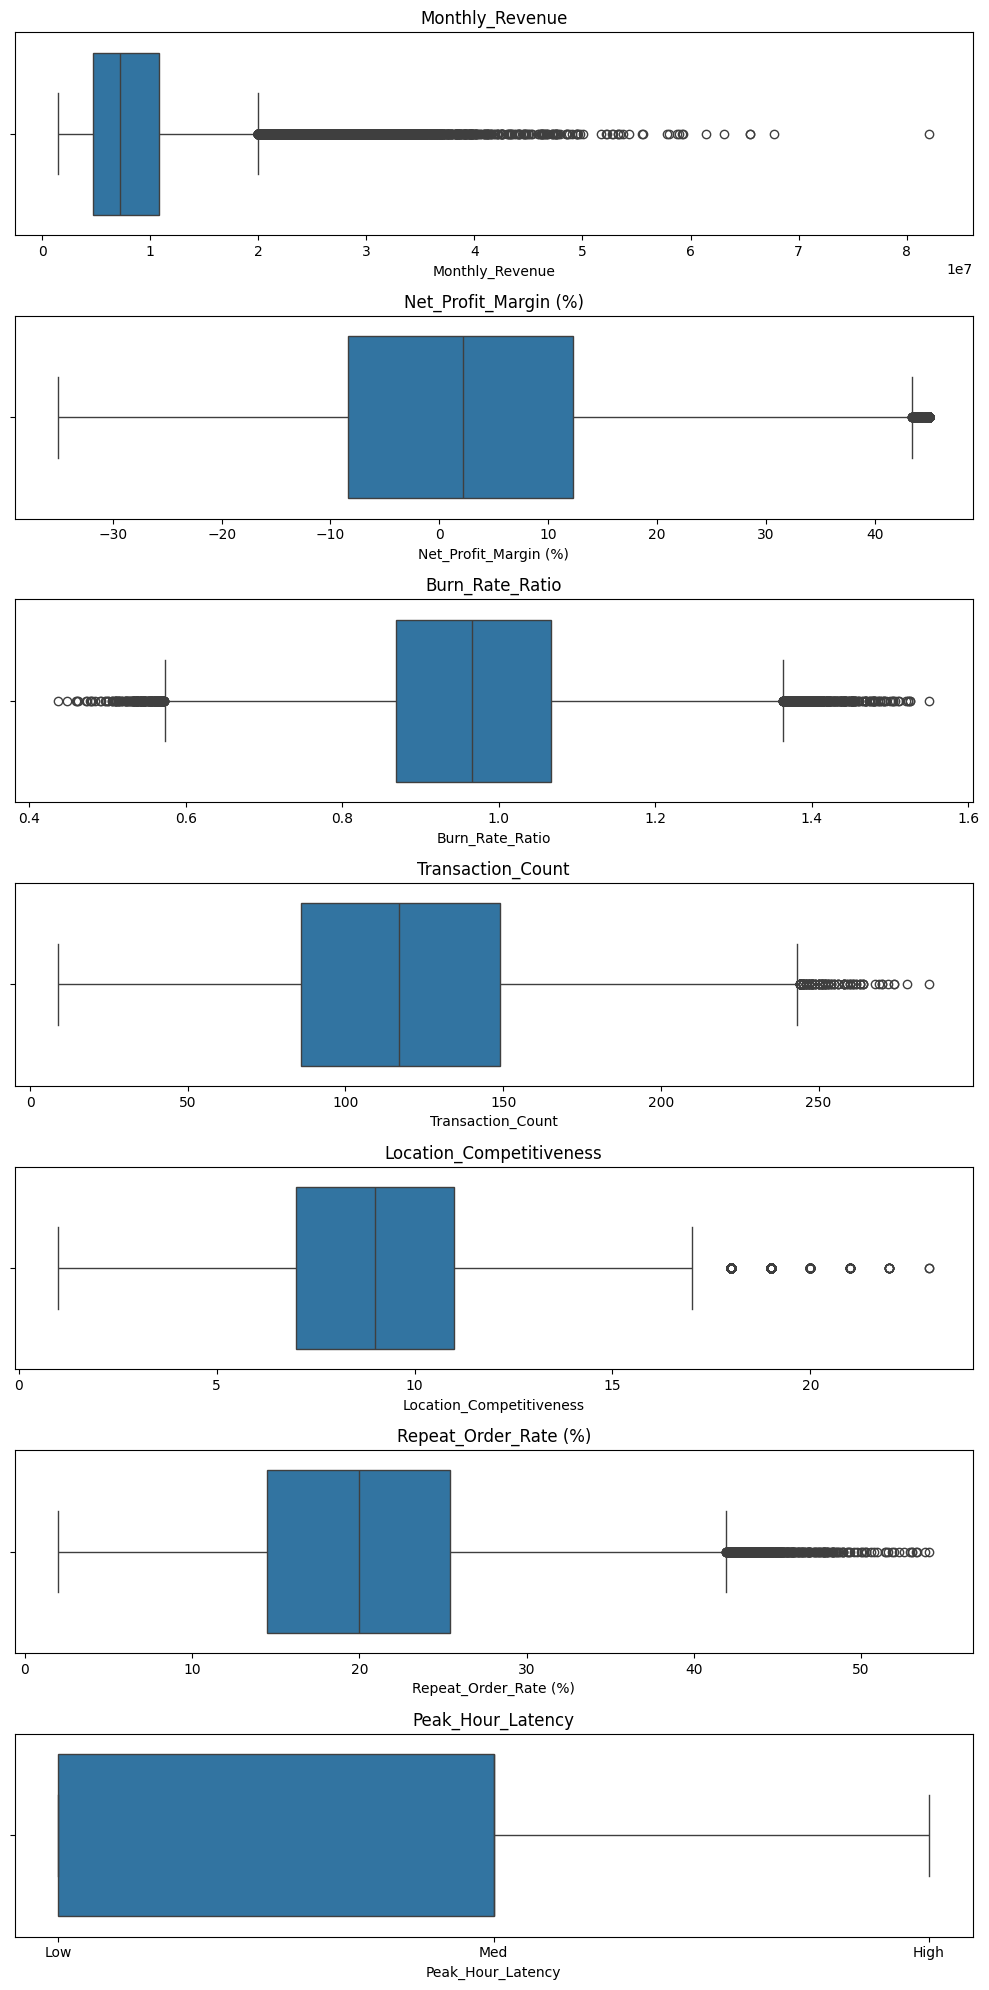

In [10]:
cols = [
    'Monthly_Revenue',
    'Net_Profit_Margin (%)',
    'Burn_Rate_Ratio',
    'Transaction_Count',
    'Location_Competitiveness',
    'Repeat_Order_Rate (%)',
    'Peak_Hour_Latency'
]

fig, axes = plt.subplots(len(cols), 1, figsize=(10,20))

for i, col in enumerate(cols):
    sns.boxplot(
        x=df[col],
        ax=axes[i]
    )
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

## Pembersihan Outliers

In [11]:
# Menentukan kolom numerik yang berpotensi memiliki outlier
num_cols = ['Monthly_Revenue', 'Net_Profit_Margin (%)', 'Burn_Rate_Ratio', 'Transaction_Count', 'Location_Competitiveness', 'Repeat_Order_Rate (%)']

# Menghitung IQR untuk setiap kolom numerik
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

# Menentukan batas bawah dan atas untuk mendeteksi outlier
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

umkm_data_cleaned = df.copy()

print(f"Jumlah data sebelum menghapus outlier: {len(df)}")
print(f"Jumlah data setelah menghapus outlier: {len(umkm_data_cleaned)}")
print(f"Outlier yang dideteksi (tidak dihapus): {((df[num_cols] < lower_bound) | (df[num_cols] > upper_bound)).any(axis=1).sum()}")

Jumlah data sebelum menghapus outlier: 150000
Jumlah data setelah menghapus outlier: 150000
Outlier yang dideteksi (tidak dihapus): 7398


#Sesudah Dilakukannya Proses Pembersihan Pada Outliers

## **Ringkasan Data**

In [12]:
total_rows, total_cols = df.shape
total_missing = df.isnull().sum().sum()
total_duplicates = df.duplicated().sum()

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("=== RINGKASAN KUALITAS DATA ===")
print(f"Jumlah baris                 : {total_rows}")
print(f"Jumlah kolom                 : {total_cols}")
print(f"Total missing value          : {total_missing}")
print(f"Total data duplikat          : {total_duplicates}")
print(f"Jumlah kolom numerik         : {len(numeric_cols)}")
print(f"Jumlah kolom kategorikal     : {len(categorical_cols)}")

print("\n=== STATUS DATA ===")

if total_missing == 0:
    print("✅ Tidak ada missing value.")
else:
    print("⚠️ Ada missing value, perlu dibersihkan.")

if total_duplicates == 0:
    print("✅ Tidak ada data duplikat.")
else:
    print("⚠️ Ada data duplikat, perlu dicek atau dihapus.")

print("\nKolom numerik:")
print(list(numeric_cols))

print("\nKolom kategorikal:")
print(list(categorical_cols))

=== RINGKASAN KUALITAS DATA ===
Jumlah baris                 : 150000
Jumlah kolom                 : 13
Total missing value          : 0
Total data duplikat          : 0
Jumlah kolom numerik         : 11
Jumlah kolom kategorikal     : 2

=== STATUS DATA ===
✅ Tidak ada missing value.
✅ Tidak ada data duplikat.

Kolom numerik:
['Monthly_Revenue', 'Net_Profit_Margin (%)', 'Burn_Rate_Ratio', 'Transaction_Count', 'Avg_Historical_Rating', 'Review_Volatility', 'Business_Tenure_Months', 'Repeat_Order_Rate (%)', 'Digital_Adoption_Score', 'Location_Competitiveness', 'Sentiment_Score']

Kolom kategorikal:
['Peak_Hour_Latency', 'Class']


#Data Preprocessing & Feature Engineering

In [13]:
# 1. Encoding operasional (Kategorikal ke Numerik)
latency_mapping = {'Low': 1, 'Med': 2, 'High': 3}
df['Peak_Hour_Latency_Numeric'] = df['Peak_Hour_Latency'].map(latency_mapping)

# 2. Feature Engineering (Membuat metrik baru)
df['Profit_Per_Transaction'] = (df['Monthly_Revenue'] * df['Net_Profit_Margin (%)'] / 100) / df['Transaction_Count']
df['Log_Monthly_Revenue'] = np.log1p(df['Monthly_Revenue'])

print("Feature Engineering Selesai. Kolom baru telah ditambahkan.")

Feature Engineering Selesai. Kolom baru telah ditambahkan.


# Function Definitions

# Perbandingan
High Digital Adoption vs Low Digital Adoption.

In [14]:
# [HEADER] A/B Testing: Digital Adoption Impact
from scipy import stats

# Membagi kelompok berdasarkan median Digital_Adoption_Score
median_adoption = df['Digital_Adoption_Score'].median()
group_high = df[df['Digital_Adoption_Score'] >= median_adoption]['Monthly_Revenue']
group_low = df[df['Digital_Adoption_Score'] < median_adoption]['Monthly_Revenue']

# Melakukan T-Test
t_stat, p_val = stats.ttest_ind(group_high, group_low)

print(f"Rata-rata Pendapatan High Adoption: {group_high.mean():.2f}")
print(f"Rata-rata Pendapatan Low Adoption: {group_low.mean():.2f}")
print(f"P-Value: {p_val:.4f}")

if p_val < 0.05:
    print("Kesimpulan: Terdapat perbedaan signifikan secara statistik antara kedua kelompok.")
else:
    print("Kesimpulan: Tidak terdapat perbedaan signifikan secara statistik.")

Rata-rata Pendapatan High Adoption: 9329879.65
Rata-rata Pendapatan Low Adoption: 7570899.46
P-Value: 0.0000
Kesimpulan: Terdapat perbedaan signifikan secara statistik antara kedua kelompok.


# Explanatory Analysis

Analisis Hubungan Antar Variabel:
- Melalui Heatmap ini, kita dapat melihat gambaran besar korelasi antar variabel operasional dan finansial untuk menentukan fitur mana yang paling berpengaruh terhadap kesehatan bisnis.

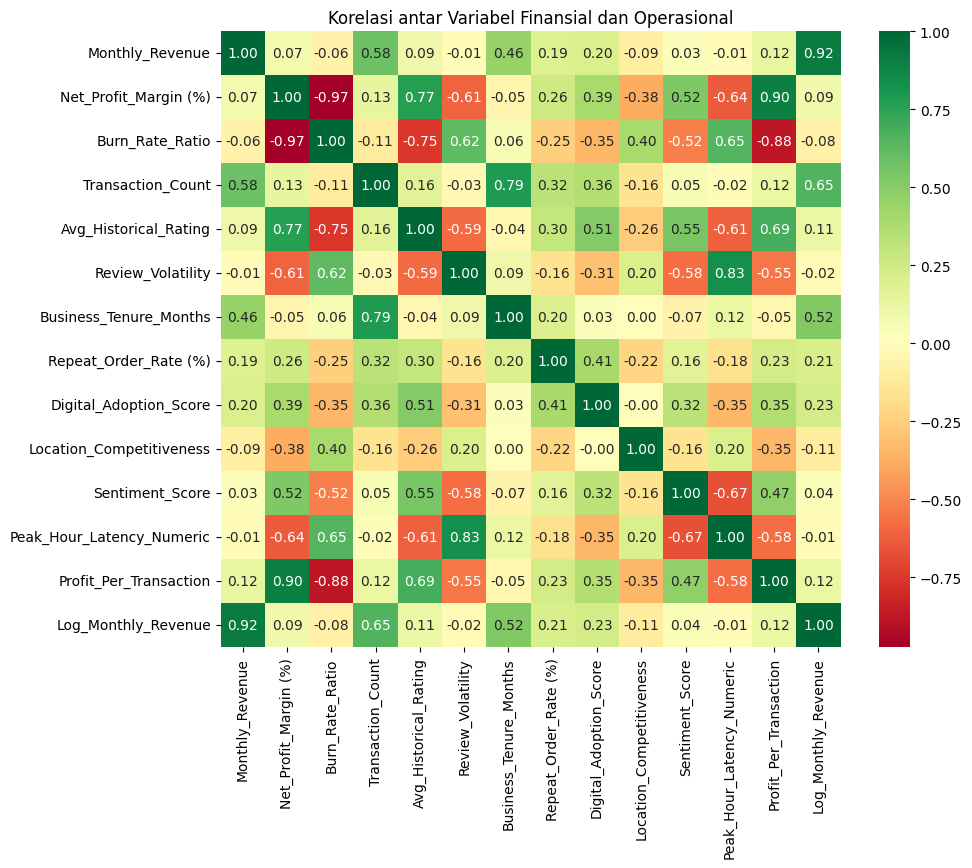

In [15]:
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Korelasi antar Variabel Finansial dan Operasional')
plt.show()

# **Menjawab Pertanyaan Bisnis**

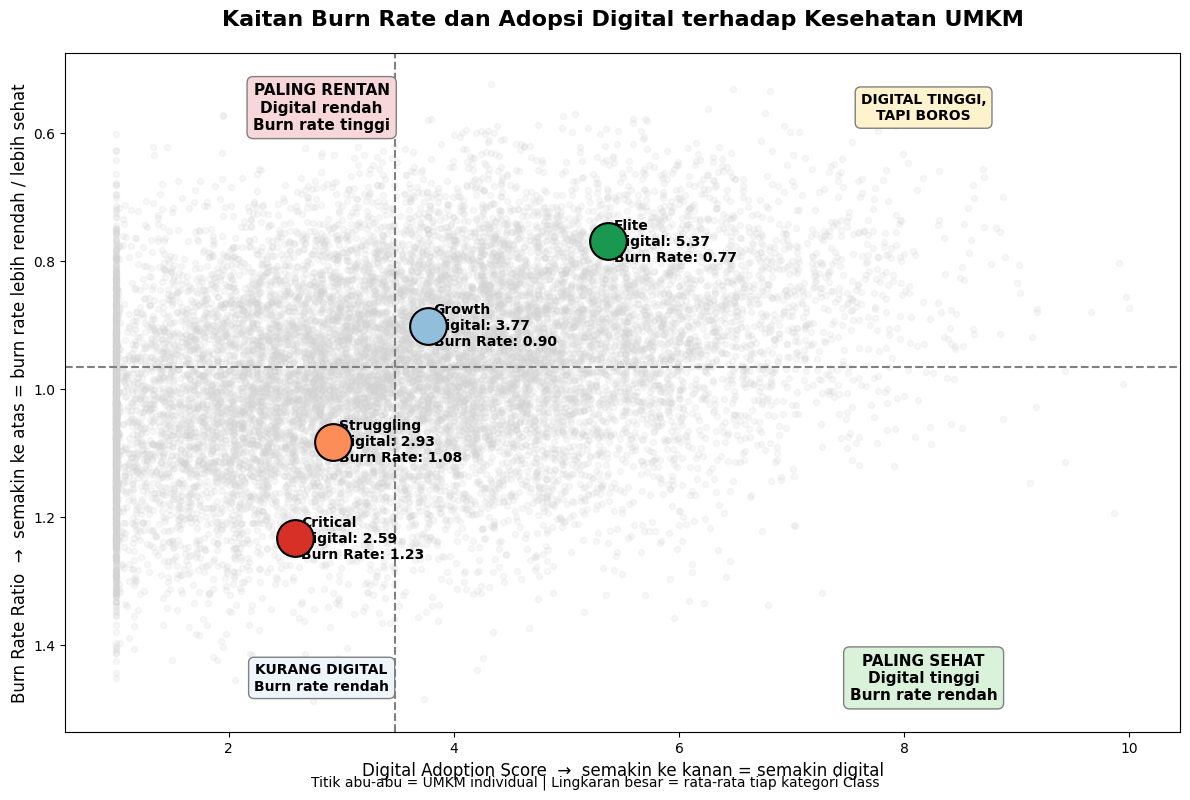

In [16]:
plot_df = df[['Burn_Rate_Ratio', 'Digital_Adoption_Score', 'Class']].dropna().copy()

if len(plot_df) > 15000:
    plot_df_sample = plot_df.sample(15000, random_state=42)
else:
    plot_df_sample = plot_df.copy()

class_order = ['Critical', 'Struggling', 'Growth', 'Elite']

summary = (
    plot_df.groupby('Class')
    .agg(
        avg_burn=('Burn_Rate_Ratio', 'mean'),
        avg_digital=('Digital_Adoption_Score', 'mean'),
        jumlah_umkm=('Class', 'count')
    )
    .reset_index()
)

summary['Class'] = pd.Categorical(summary['Class'], categories=class_order, ordered=True)
summary = summary.sort_values('Class')

x_mid = plot_df['Digital_Adoption_Score'].median()
y_mid = plot_df['Burn_Rate_Ratio'].median()

color_map = {
    'Critical': '#d73027',
    'Struggling': '#fc8d59',
    'Growth': '#91bfdb',
    'Elite': '#1a9850'
}

plt.figure(figsize=(12, 8))
ax = plt.gca()

plt.scatter(
    plot_df_sample['Digital_Adoption_Score'],
    plot_df_sample['Burn_Rate_Ratio'],
    color='lightgray',
    alpha=0.18,
    s=18,
    label='UMKM individual'
)

for _, row in summary.iterrows():
    plt.scatter(
        row['avg_digital'],
        row['avg_burn'],
        s=700,
        color=color_map[row['Class']],
        edgecolor='black',
        linewidth=1.5,
        zorder=5
    )

    plt.text(
        row['avg_digital'] + 0.05,
        row['avg_burn'],
        f"{row['Class']}\nDigital: {row['avg_digital']:.2f}\nBurn Rate: {row['avg_burn']:.2f}",
        fontsize=10,
        weight='bold',
        va='center'
    )

plt.axvline(x=x_mid, color='gray', linestyle='--', linewidth=1.5)
plt.axhline(y=y_mid, color='gray', linestyle='--', linewidth=1.5)

ax.invert_yaxis()

plt.title(
    'Kaitan Burn Rate dan Adopsi Digital terhadap Kesehatan UMKM',
    fontsize=16,
    weight='bold',
    pad=20
)

plt.xlabel('Digital Adoption Score  →  semakin ke kanan = semakin digital', fontsize=12)
plt.ylabel('Burn Rate Ratio  →  semakin ke atas = burn rate lebih rendah / lebih sehat', fontsize=12)

ax.text(0.77, 0.08, 'PALING SEHAT\nDigital tinggi\nBurn rate rendah',
        transform=ax.transAxes, fontsize=11, weight='bold',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#d9f2d9', edgecolor='gray'))

ax.text(0.23, 0.08, 'KURANG DIGITAL\nBurn rate rendah',
        transform=ax.transAxes, fontsize=10, weight='bold',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#eef5fb', edgecolor='gray'))

ax.text(0.77, 0.92, 'DIGITAL TINGGI,\nTAPI BOROS',
        transform=ax.transAxes, fontsize=10, weight='bold',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff3cd', edgecolor='gray'))

ax.text(0.23, 0.92, 'PALING RENTAN\nDigital rendah\nBurn rate tinggi',
        transform=ax.transAxes, fontsize=11, weight='bold',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8d7da', edgecolor='gray'))

plt.figtext(
    0.5, 0.01,
    'Titik abu-abu = UMKM individual | Lingkaran besar = rata-rata tiap kategori Class',
    ha='center',
    fontsize=10
)

plt.tight_layout()
plt.show()

# **Analisis Kaitan Burn Rate Ratio dan Digital Adoption Score terhadap Kesehatan UMKM**

---

Analisis terhadap scatter plot menunjukkan adanya pola korelasi yang konsisten dan signifikan antara tingkat adopsi digital dan efisiensi pengeluaran (burn rate ratio) pada UMKM. Keempat kategori UMKM — Elite, Growth, Struggling, dan Critical — membentuk gradasi yang jelas dari kiri-bawah menuju kanan-atas pada grafik, mengindikasikan bahwa semakin tinggi adopsi digital suatu UMKM, semakin rendah burn rate-nya, dan semakin baik kesehatan bisnisnya secara keseluruhan.

---

## **Posisi Kategori UMKM pada Matriks**

| Kategori | Digital Adoption Score | Burn Rate Ratio | Status Kesehatan |
|---|---|---|---|
| Elite | 5.37 | 0.77 | Sehat |
| Growth | 3.77 | 0.90 | Berkembang |
| Struggling | 2.93 | 1.08 | Rentan |
| Critical | 2.59 | 1.23 | Berbahaya |

> Perlu dicatat bahwa sumbu vertikal pada grafik bersifat terbalik posisi semakin ke atas mencerminkan burn rate yang semakin rendah atau kondisi yang lebih sehat. Garis putus-putus horizontal pada angka 1.0 menjadi batas kritis: UMKM yang berada di bawah garis ini memiliki pengeluaran yang melebihi pendapatan, sebuah kondisi yang tidak berkelanjutan dalam jangka panjang.



---

# **Temuan dan Interpretasi**

### **Pola Korelasi Sistematis**

Hal paling mencolok dari grafik ini adalah terbentuknya garis diagonal yang jelas antara keempat kategori. Ini bukan sebaran acak, melainkan pola terstruktur yang mencerminkan hubungan sebab-akibat antara digitalisasi dan efisiensi keuangan. UMKM Elite dengan digital score 5.37 berhasil menjaga burn rate di angka 0.77 — artinya mereka hanya menggunakan 77% dari pendapatan untuk menutup pengeluaran, menyisakan 23% sebagai surplus. Sebaliknya, UMKM Critical dengan digital score 2.59 justru memiliki burn rate 1.23, yang berarti mereka menghabiskan 23% lebih banyak dari yang mereka hasilkan setiap bulannya.

### **Garis Bahaya: Burn Rate di Atas 1.0**

Dua kategori bawah — Struggling dan Critical — telah melewati ambang batas 1.0. Kondisi ini secara teknis berarti operasional mereka dibiayai oleh modal atau utang, bukan dari hasil usaha. UMKM Struggling berada di angka 1.08, masih dalam zona yang dapat diperbaiki dengan intervensi tepat. Namun UMKM Critical di angka 1.23 berada dalam kondisi yang jauh lebih mengkhawatirkan dan memerlukan restrukturisasi menyeluruh, bukan sekadar perbaikan marginal.

### **Gap Digital yang Menjadi Akar Masalah**

Jarak digital score antara Elite (5.37) dan Critical (2.59) mencapai 2.78 poin — hampir dua kali lipat. Ini bukan sekadar angka; perbedaan ini mencerminkan kesenjangan dalam kemampuan operasional, jangkauan pasar, dan kontrol keuangan. UMKM yang sudah mengadopsi teknologi secara lebih luas cenderung memiliki pencatatan keuangan yang lebih akurat, proses pemasaran yang lebih efisien, dan kemampuan yang lebih baik dalam mendeteksi kebocoran biaya sebelum berkembang menjadi masalah besar.

### **Peringatan dari Kuadran Kanan-Atas**

Grafik juga memperlihatkan kluster UMKM di kuadran kanan-atas — kelompok yang memiliki digital score tinggi namun burn rate-nya juga tinggi. Fenomena ini penting untuk dicermati karena menunjukkan bahwa adopsi digital semata tidak menjamin kesehatan keuangan. Teknologi yang tidak diimplementasikan dengan perencanaan yang matang justru dapat menambah beban biaya operasional tanpa menghasilkan efisiensi yang sepadan. Ini menjadi peringatan bahwa digitalisasi harus berjalan beriringan dengan literasi keuangan dan manajemen biaya yang disiplin.

---

# **Mekanisme: Mengapa Adopsi Digital Menekan Burn Rate**

Korelasi yang terlihat pada grafik bukan bersifat kebetulan. Terdapat mekanisme nyata yang menjelaskan mengapa UMKM dengan adopsi digital lebih tinggi cenderung memiliki burn rate lebih rendah. Pencatatan keuangan berbasis aplikasi memungkinkan pemilik usaha mendeteksi kebocoran biaya secara lebih cepat dan akurat dibandingkan pencatatan manual. Pemasaran melalui platform digital secara signifikan menekan biaya akuisisi pelanggan baru dibandingkan metode konvensional. Manajemen inventaris berbasis sistem digital mengurangi risiko overstock yang selama ini menjadi salah satu sumber pemborosan terbesar di kalangan UMKM. Selain itu, transaksi non-tunai mempermudah rekonsiliasi arus kas dan meminimalkan selisih pencatatan yang sering terjadi pada usaha berbasis uang tunai.

Namun demikian, semua manfaat di atas hanya terwujud apabila adopsi digital dilakukan secara terencana dan diiringi dengan pemahaman yang cukup dari pemilik usaha.

---

# **Rekomendasi Strategis**

### Untuk UMKM Critical dan Struggling

Prioritas utama bagi kedua kelompok ini adalah menstabilkan kondisi keuangan terlebih dahulu sebelum membicarakan ekspansi atau digitalisasi besar-besaran. Langkah pertama yang harus dilakukan adalah audit menyeluruh terhadap seluruh pos pengeluaran untuk mengidentifikasi komponen biaya yang tidak memberikan kontribusi langsung terhadap pendapatan. Target realistis dalam tiga bulan pertama adalah menurunkan burn rate hingga mendekati angka 1.0 — titik impas — sebagai landasan sebelum dapat bergerak lebih jauh.

Setelah stabilisasi tercapai, digitalisasi dapat dimulai secara bertahap dari titik yang memberikan dampak langsung dan terukur. Pencatatan keuangan digital adalah langkah pertama yang paling krusial karena memberikan visibilitas atas kondisi bisnis secara real-time. Barulah kemudian dilanjutkan ke pemasaran digital melalui marketplace atau media sosial untuk memperluas jangkauan tanpa biaya pemasaran yang besar.

### Untuk UMKM Growth

Kategori ini sudah berada di jalur yang benar dengan burn rate di bawah 1.0 dan digital score yang terus berkembang. Fokus rekomendasi untuk kelompok ini adalah mempercepat laju digitalisasi secara terukur, khususnya pada aspek yang dapat mengkonversi digital presence menjadi efisiensi biaya dan peningkatan loyalitas pelanggan. Gap digital score antara Growth (3.77) dan Elite (5.37) relatif dapat dijembatani dalam waktu 6 hingga 12 bulan apabila ada komitmen dan arah yang jelas.

### Untuk UMKM Elite

Tantangan utama bagi kelompok Elite bukan lagi soal peningkatan, melainkan konsistensi dan kehati-hatian. Risiko terbesar bagi UMKM Elite adalah terjebak ke dalam kuadran "Digital Tinggi Tapi Boros" akibat investasi teknologi yang tidak terukur ROI-nya. Setiap penambahan tools atau platform digital perlu dievaluasi secara berkala berdasarkan kontribusinya terhadap efisiensi atau pendapatan. Di sisi lain, UMKM Elite memiliki potensi besar untuk berperan sebagai anchor dalam ekosistem UMKM lokal — baik sebagai mitra, pembeli, maupun referensi praktik terbaik bagi kategori di bawahnya.

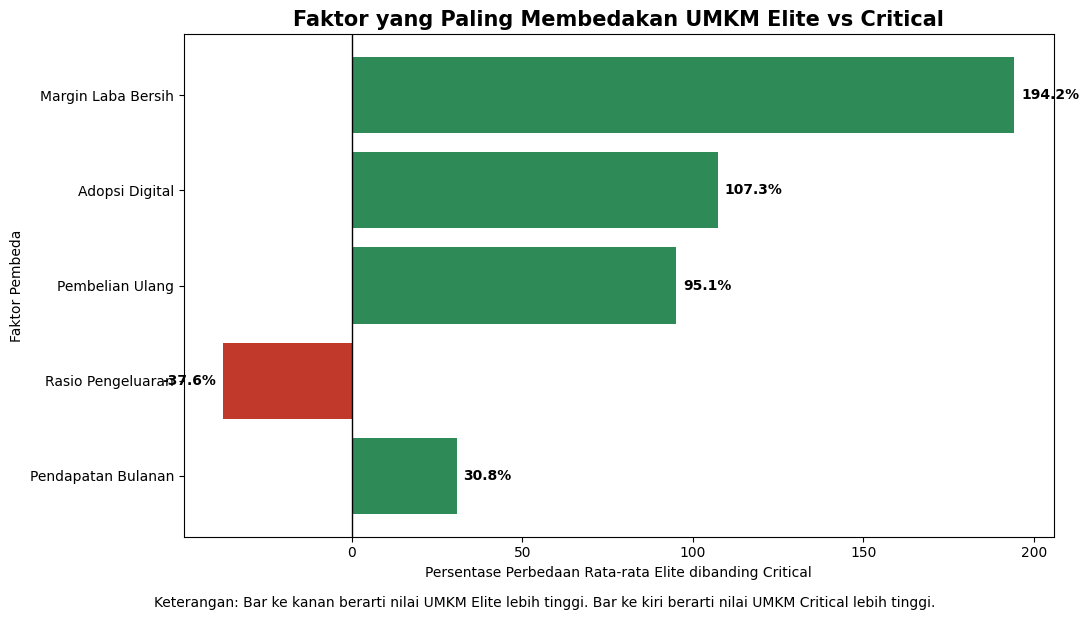

In [17]:
# Filter hanya UMKM Elite dan Critical
df_ec = df[df['Class'].isin(['Elite', 'Critical'])].copy()

# Variabel yang dianalisis
features = [
    'Monthly_Revenue',
    'Net_Profit_Margin (%)',
    'Burn_Rate_Ratio',
    'Repeat_Order_Rate (%)',
    'Digital_Adoption_Score'
]

# Label yang lebih mudah dipahami orang awam
feature_labels = {
    'Monthly_Revenue': 'Pendapatan Bulanan',
    'Net_Profit_Margin (%)': 'Margin Laba Bersih',
    'Burn_Rate_Ratio': 'Rasio Pengeluaran',
    'Repeat_Order_Rate (%)': 'Pembelian Ulang',
    'Digital_Adoption_Score': 'Adopsi Digital'
}

# Hitung rata-rata Elite dan Critical
mean_values = df_ec.groupby('Class')[features].mean()

# Hitung persentase perbedaan:
# positif = Elite lebih tinggi
# negatif = Critical lebih tinggi
diff_pct = ((mean_values.loc['Elite'] - mean_values.loc['Critical']) / mean_values.loc['Critical'].abs()) * 100

# Buat dataframe untuk visualisasi
plot_df = pd.DataFrame({
    'Faktor': diff_pct.index.map(feature_labels),
    'Persentase_Perbedaan': diff_pct.values
})

# Urutkan dari faktor pembeda terbesar
plot_df['Besar_Perbedaan'] = plot_df['Persentase_Perbedaan'].abs()
plot_df = plot_df.sort_values('Besar_Perbedaan', ascending=True)

# Warna: hijau jika Elite lebih tinggi, merah jika Critical lebih tinggi
colors = ['#2E8B57' if x > 0 else '#C0392B' for x in plot_df['Persentase_Perbedaan']]

# Buat visualisasi
plt.figure(figsize=(11, 6))
bars = plt.barh(
    plot_df['Faktor'],
    plot_df['Persentase_Perbedaan'],
    color=colors
)

# Garis tengah
plt.axvline(0, color='black', linewidth=1)

# Label angka di setiap bar
for bar in bars:
    width = bar.get_width()
    label_position = width + 2 if width > 0 else width - 2
    alignment = 'left' if width > 0 else 'right'

    plt.text(
        label_position,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.1f}%',
        va='center',
        ha=alignment,
        fontsize=10,
        fontweight='bold'
    )

# Judul dan keterangan
plt.title(
    'Faktor yang Paling Membedakan UMKM Elite vs Critical',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Persentase Perbedaan Rata-rata Elite dibanding Critical')
plt.ylabel('Faktor Pembeda')

# Tambahkan keterangan sederhana
plt.figtext(
    0.5, -0.02,
    'Keterangan: Bar ke kanan berarti nilai UMKM Elite lebih tinggi. Bar ke kiri berarti nilai UMKM Critical lebih tinggi.',
    ha='center',
    fontsize=10
)

plt.tight_layout()
plt.show()

### **Pertanyaan : Faktor apa yang paling membedakan UMKM kategori Elite dengan UMKM kategori Critical berdasarkan revenue, profit margin, burn rate, repeat order, dan digital adoption score?**

1. **Margin Laba Bersih** - Faktor paling kritis (194.2%)

    Ini adalah pembeda terbesar antara Elite dan Critical. UMKM Elite mampu mengkonversi revenue menjadi profit hampir 3x lebih efektif. Artinya bukan soal seberapa besar omzet, tapi seberapa efisien menghasilkan laba.

2. **Adopsi Digital** - Faktor Akselerator (107.3%)

    UMKM Elite 2x lebih digital dibanding Critical. Adopsi digital yang tinggi memungkinkan otomasi, jangkauan pasar lebih luas, dan efisiensi operasional yang langsung berdampak ke profitabilitas.

3. **Pembelian Ulang** — Indikator Loyalitas (95.1%)

    Elite hampir 2x lebih baik dalam mempertahankan pelanggan. Ini menunjukkan kualitas produk/layanan dan pengalaman pelanggan yang jauh lebih unggul, serta biaya akuisisi pelanggan yang lebih rendah.

4.  **Rasio Pengeluaran** — Tanda Bahaya Critical (-37.6%)

    UMKM Critical justru lebih boros 37.6% dibanding Elite. Ini adalah burn rate yang tinggi — pengeluaran tidak terkontrol menjadi akar masalah mengapa margin mereka rendah.

5.  **Pendapatan Bulanan** — Perbedaan Moderat (30.8%)

    Menariknya, gap revenue hanya 30.8%, namun gap margin mencapai 194.2%. Ini membuktikan bahwa masalah UMKM Critical bukan di pendapatan, melainkan di manajemen biaya dan efisiensi.


---

### **💡Berikut Adalah Rekomenadasi Bisnis Yang Bisa Dilakukan Untuk UMKM Critical**



*   **Prioritas 1** — Bedah Struktur Biaya

    Lakukan audit menyeluruh terhadap komponen pengeluaran. Identifikasi cost leakage — pengeluaran yang tidak menghasilkan nilai (supplier mahal, inefisiensi proses, pemborosan operasional). Target: tekan rasio pengeluaran minimal 15–20% dalam 3 bulan pertama.

*   **Prioritas 2** — Digitalisasi Bertahap

    Mulai dari yang berdampak langsung: pencatatan keuangan digital (misalnya BukuKas, Jurnal.id), lalu masuk ke pemasaran digital (marketplace, WhatsApp Business). Gap 107.3% di adopsi digital adalah peluang terbesar untuk naik kelas.

*   **Prioritas 3** — Program Retensi Pelanggan

    Bangun sistem sederhana untuk mendorong repeat order: loyalty card, follow-up WhatsApp, atau bundling produk. Meningkatkan repeat order 10% lebih murah daripada mencari 10% pelanggan baru.

*   **Prioritas 4** — Repricing & Margin Management

    Evaluasi harga jual. Banyak UMKM Critical underpricing karena takut kehilangan pelanggan, padahal justru membunuh margin. Hitung HPP secara akurat sebelum menentukan harga.


## **Data Dictionary**

In [18]:
data_dictionary_manual = pd.DataFrame({
    'Nama Kolom': [
        'ID',
        'Monthly_Revenue',
        'Net_Profit_Margin (%)',
        'Burn_Rate_Ratio',
        'Transaction_Count',
        'Avg_Historical_Rating',
        'Review_Text',
        'Review_Volatility',
        'Business_Tenure_Months',
        'Repeat_Order_Rate (%)',
        'Digital_Adoption_Score',
        'Peak_Hour_Latency',
        'Location_Competitiveness',
        'Sentiment_Score',
        'Class'
    ],
    'Tipe Data': [
        'Integer / Identifier',
        'Numerik',
        'Numerik',
        'Numerik',
        'Numerik',
        'Numerik',
        'Teks',
        'Numerik',
        'Numerik',
        'Numerik',
        'Numerik',
        'Kategorikal',
        'Numerik',
        'Numerik',
        'Kategorikal / Target'
    ],
    'Keterangan': [
        'Nomor unik untuk setiap data UMKM.',
        'Pendapatan bulanan UMKM.',
        'Persentase margin laba bersih UMKM.',
        'Rasio pengeluaran terhadap pendapatan atau kas.',
        'Jumlah transaksi dalam periode tertentu.',
        'Rata-rata rating historis pelanggan.',
        'Isi ulasan pelanggan dalam bentuk teks.',
        'Tingkat fluktuasi atau ketidakstabilan ulasan pelanggan.',
        'Lama usaha berjalan dalam satuan bulan.',
        'Persentase pelanggan yang melakukan pembelian ulang.',
        'Skor tingkat adopsi digital UMKM.',
        'Tingkat keterlambatan/respons saat jam sibuk.',
        'Skor daya saing lokasi usaha.',
        'Skor sentimen dari ulasan pelanggan.',
        'Kategori kondisi UMKM sebagai label target klasifikasi.'
    ]
})

data_dictionary_manual

,Nama Kolom,Tipe Data,Keterangan
0,ID,Integer / Identifier,Nomor unik untuk setiap data UMKM.
1,Monthly_Revenue,Numerik,Pendapatan bulanan UMKM.
2,Net_Profit_Margin (%),Numerik,Persentase margin laba bersih UMKM.
3,Burn_Rate_Ratio,Numerik,Rasio pengeluaran terhadap pendapatan atau kas.
4,Transaction_Count,Numerik,Jumlah transaksi dalam periode tertentu.
5,Avg_Historical_Rating,Numerik,Rata-rata rating historis pelanggan.
6,Review_Text,Teks,Isi ulasan pelanggan dalam bentuk teks.
7,Review_Volatility,Numerik,Tingkat fluktuasi atau ketidakstabilan ulasan ...
8,Business_Tenure_Months,Numerik,Lama usaha berjalan dalam satuan bulan.
9,Repeat_Order_Rate (%),Numerik,Persentase pelanggan yang melakukan pembelian ...


In [19]:
from IPython.display import display

display(data_dictionary_manual)

,Nama Kolom,Tipe Data,Keterangan
0,ID,Integer / Identifier,Nomor unik untuk setiap data UMKM.
1,Monthly_Revenue,Numerik,Pendapatan bulanan UMKM.
2,Net_Profit_Margin (%),Numerik,Persentase margin laba bersih UMKM.
3,Burn_Rate_Ratio,Numerik,Rasio pengeluaran terhadap pendapatan atau kas.
4,Transaction_Count,Numerik,Jumlah transaksi dalam periode tertentu.
5,Avg_Historical_Rating,Numerik,Rata-rata rating historis pelanggan.
6,Review_Text,Teks,Isi ulasan pelanggan dalam bentuk teks.
7,Review_Volatility,Numerik,Tingkat fluktuasi atau ketidakstabilan ulasan ...
8,Business_Tenure_Months,Numerik,Lama usaha berjalan dalam satuan bulan.
9,Repeat_Order_Rate (%),Numerik,Persentase pelanggan yang melakukan pembelian ...


In [20]:
umkm_data_cleaned.to_csv('synthetic_umkm_data_cleaned.csv', index=False)

Pre - Prossesing

In [21]:
df_cleaned = pd.read_csv("synthetic_umkm_data_cleaned.csv")

print("===== DATASET =====")
print(df.head())


===== DATASET =====
   Monthly_Revenue  Net_Profit_Margin (%)  Burn_Rate_Ratio  Transaction_Count  \
0          6680716                  22.72            0.811                161   
1          5819101                   4.46            0.968                104   
2          5236404                 -10.12            1.047                102   
3          8043552                   0.04            0.969                 99   
4          6071256                   4.22            0.954                115   

   Avg_Historical_Rating  Review_Volatility  Business_Tenure_Months  \
0                   4.75              0.313                     105   
1                   4.21              0.632                      95   
2                   3.51              0.470                      17   
3                   4.33              0.206                     109   
4                   4.34              0.232                      74   

   Repeat_Order_Rate (%)  Digital_Adoption_Score Peak_Hour_Latency

In [22]:
# Revenue efficiency
df_cleaned['Revenue_per_Transaction'] = (
    df_cleaned['Monthly_Revenue']
    / (df_cleaned['Transaction_Count'] + 1)
)

# Business efficiency
df_cleaned['Business_Efficiency'] = (
    df_cleaned['Net_Profit_Margin (%)']
    / (df_cleaned['Burn_Rate_Ratio'] + 1)
)

# Customer satisfaction
df_cleaned['Customer_Satisfaction_Index'] = (
    df_cleaned['Avg_Historical_Rating']
    * df_cleaned['Repeat_Order_Rate (%)']
)

# Digital monetization power
df_cleaned['Digital_Revenue_Power'] = (
    df_cleaned['Digital_Adoption_Score']
    * np.log1p(df_cleaned['Monthly_Revenue'])
)

# Risk score
df_cleaned['Risk_Score'] = (
    df_cleaned['Burn_Rate_Ratio']
    * df_cleaned['Review_Volatility']
)

# Market strength
df_cleaned['Market_Strength'] = (
    df_cleaned['Sentiment_Score']
    * df_cleaned['Location_Competitiveness']
)

# Business maturity
df_cleaned['Business_Maturity'] = (
    np.log1p(df_cleaned['Business_Tenure_Months'])
    * df_cleaned['Avg_Historical_Rating']
)


In [23]:
categorical_cols = [
    'Peak_Hour_Latency'
]

df_cleaned = pd.get_dummies(
    df_cleaned,
    columns=categorical_cols,
    drop_first=False
)

FEATURES = [
    'Net_Profit_Margin (%)',
    'Burn_Rate_Ratio',
    'Digital_Adoption_Score',
    'Repeat_Order_Rate (%)',
    'Avg_Historical_Rating',
    'Review_Volatility',
    'Sentiment_Score',
    'Monthly_Revenue',
    'Transaction_Count',
    'Location_Competitiveness',
    'Business_Tenure_Months',

    # DUMMIES
    'Peak_Hour_Latency_Low',
    'Peak_Hour_Latency_Med',
    'Peak_Hour_Latency_High'
]

X_raw = df_cleaned[FEATURES].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

In [24]:
X = df_cleaned[FEATURES].copy()

In [25]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

In [26]:
noise_factor = 0.1
X_noisy = X_imputed + np.random.normal(
    0,
    noise_factor * X_imputed.std(axis=0),
    X_imputed.shape
)

In [27]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_raw)

In [28]:
inertia = []
sil_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_, sample_size=3000))
    print(f"K={k} | Silhouette: {sil_scores[-1]:.4f}")

best_k = K_range[sil_scores.index(max(sil_scores))]
print(f"\nK terbaik (silhouette): {best_k}")

K=2 | Silhouette: 0.2329
K=3 | Silhouette: 0.2594
K=4 | Silhouette: 0.2025
K=5 | Silhouette: 0.1942
K=6 | Silhouette: 0.1635
K=7 | Silhouette: 0.1581
K=8 | Silhouette: 0.1532
K=9 | Silhouette: 0.1433

K terbaik (silhouette): 3


In [29]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cleaned['Cluster'] = km.fit_predict(X_scaled)

CLUSTER_RECO = {
    0: 'Optimasi_Operasional',
    1: 'Skala_Bisnis',
    2: 'Stabilisasi_Digital',
    3: 'Restrukturisasi_Keuangan'
}
df_cleaned['Rekomendasi'] = df_cleaned['Cluster'].map(CLUSTER_RECO)

print(df_cleaned['Rekomendasi'].value_counts())

Rekomendasi
Skala_Bisnis                52139
Optimasi_Operasional        36745
Restrukturisasi_Keuangan    34841
Stabilisasi_Digital         26275
Name: count, dtype: int64


In [30]:
le = LabelEncoder()
y = le.fit_transform(df_cleaned['Class'])

X = df_cleaned[FEATURES].copy()
X_imputed = imputer.transform(X)  # pakai imputer yang sudah fit sebelumnya

X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

scaler2 = StandardScaler()
X_train_scaled = scaler2.fit_transform(X_train)
X_test_scaled = scaler2.transform(X_test)

model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42
)

model.fit(X_train_scaled, y_train)  # fix: pakai scaled
y_pred = model.predict(X_test_scaled)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cv_scores = cross_val_score(model, X_imputed, y, cv=5, scoring='accuracy')  # fix: X_imputed
print(f"Cross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


Classification Report:
              precision    recall  f1-score   support

    Critical       0.99      0.99      0.99      2434
       Elite       0.99      1.00      1.00      2052
      Growth       1.00      1.00      1.00     17203
  Struggling       0.99      0.99      0.99      8311

    accuracy                           1.00     30000
   macro avg       0.99      1.00      0.99     30000
weighted avg       1.00      1.00      1.00     30000

Cross-Validation Accuracy: 0.9962 ± 0.0006


In [31]:
correlation = pd.DataFrame(X_imputed, columns=FEATURES).corrwith(pd.Series(y))
print(correlation.abs().sort_values(ascending=False))

Peak_Hour_Latency_Med       0.178563
Peak_Hour_Latency_Low       0.128838
Digital_Adoption_Score      0.098665
Review_Volatility           0.078670
Sentiment_Score             0.070935
Peak_Hour_Latency_High      0.070649
Avg_Historical_Rating       0.054263
Repeat_Order_Rate (%)       0.048332
Net_Profit_Margin (%)       0.030365
Location_Competitiveness    0.028599
Transaction_Count           0.019895
Monthly_Revenue             0.008751
Business_Tenure_Months      0.006538
Burn_Rate_Ratio             0.005700
dtype: float64


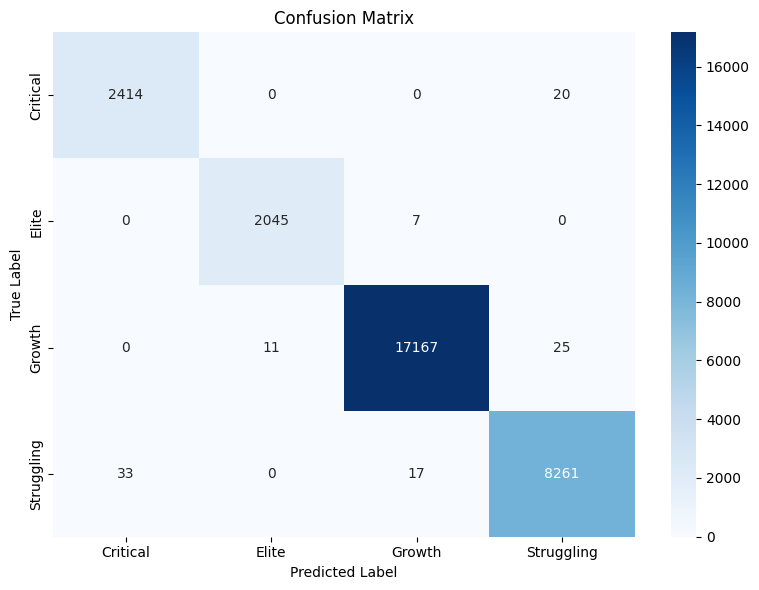

In [32]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

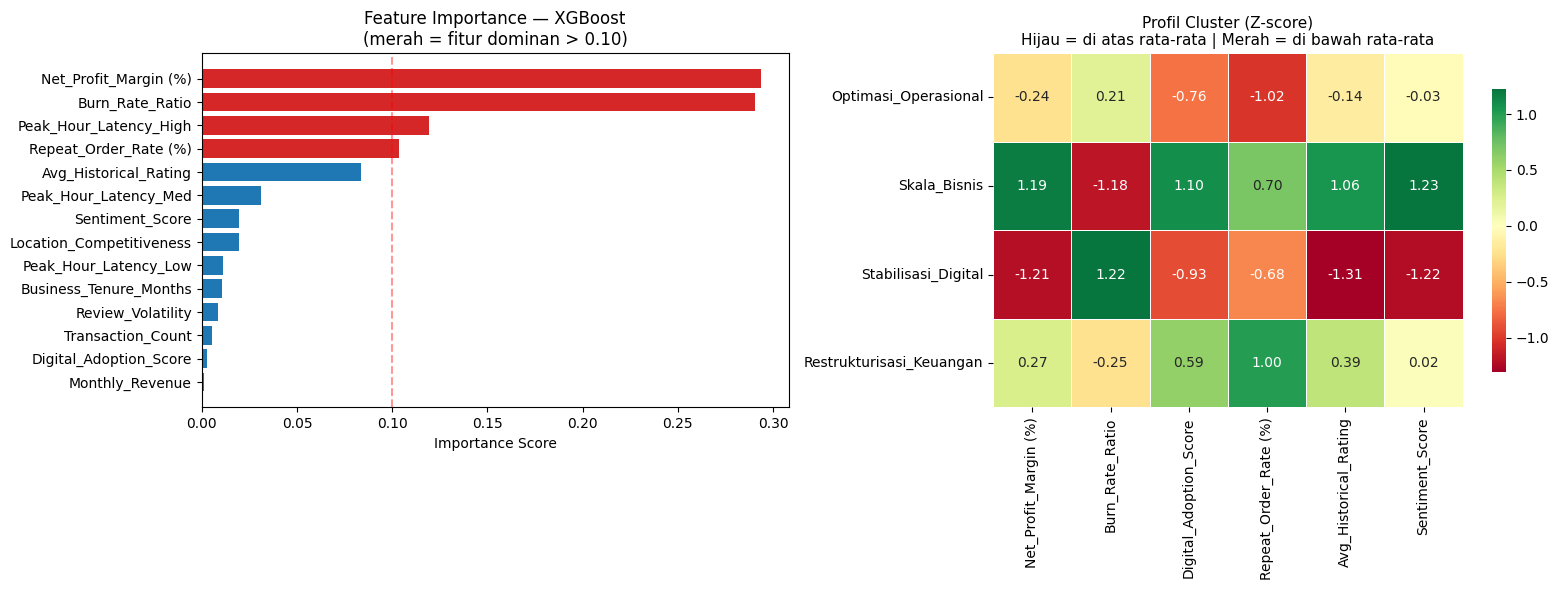

In [33]:
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Feature Importance
colors = ['#d62728' if imp > 0.10 else '#1f77b4' for imp in importances.values]
axes[0].barh(importances.index, importances.values, color=colors)
axes[0].set_xlabel('Importance Score')
axes[0].set_title('Feature Importance — XGBoost\n(merah = fitur dominan > 0.10)', fontsize=12)
axes[0].axvline(x=0.10, color='red', linestyle='--', alpha=0.4)

# Cluster Profile Heatmap
profile_cols = ['Net_Profit_Margin (%)', 'Burn_Rate_Ratio', 'Digital_Adoption_Score',
                'Repeat_Order_Rate (%)', 'Avg_Historical_Rating', 'Sentiment_Score']
cluster_labels = [CLUSTER_RECO[i] for i in sorted(CLUSTER_RECO.keys())]

profile_df = df_cleaned.groupby('Cluster')[profile_cols].mean()
profile_norm = (profile_df - profile_df.mean()) / profile_df.std()
profile_norm.index = cluster_labels

sns.heatmap(profile_norm, cmap='RdYlGn', center=0, annot=True, fmt='.2f',
            ax=axes[1], linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[1].set_title('Profil Cluster (Z-score)\nHijau = di atas rata-rata | Merah = di bawah rata-rata', fontsize=11)
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('umkm_clustering_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
profile_cols = [
    'Net_Profit_Margin (%)',
    'Burn_Rate_Ratio',
    'Digital_Adoption_Score',
    'Repeat_Order_Rate (%)',
    'Avg_Historical_Rating',
    'Sentiment_Score',
    'Business_Efficiency',
    'Risk_Score'
]

cluster_labels = [
    CLUSTER_RECO[i]
    for i in sorted(CLUSTER_RECO.keys())
]

profile_df = df_cleaned.groupby('Cluster')[profile_cols].mean()

profile_norm = (
    (profile_df - profile_df.mean())
    / profile_df.std()
)

profile_norm.index = cluster_labels

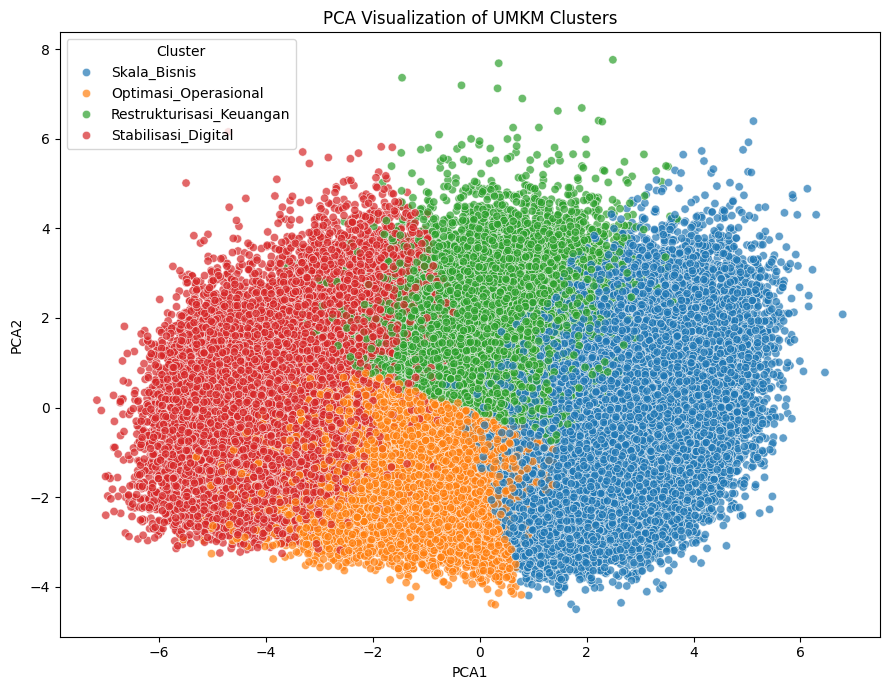

In [35]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    'PCA1': X_pca[:, 0],
    'PCA2': X_pca[:, 1],
    'Cluster': df_cleaned['Rekomendasi']
})

plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=pca_df,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    alpha=0.7
)

plt.title('PCA Visualization of UMKM Clusters')

plt.tight_layout()
plt.show()


In [36]:
print("\n" + "="*70)
print("BUSINESS INSIGHT SUMMARY\n")

for cluster_name in cluster_labels:

    print(f"▶ {cluster_name}")

    cluster_data = profile_norm.loc[cluster_name]

    top_positive = cluster_data.sort_values(
        ascending=False
    ).head(3)

    top_negative = cluster_data.sort_values(
        ascending=True
    ).head(3)

    print("\n  Kekuatan:")
    for idx, val in top_positive.items():
        print(f"   + {idx}: {val:.2f}")

    print("\n  Risiko:")
    for idx, val in top_negative.items():
        print(f"   - {idx}: {val:.2f}")

    print("\n" + "-"*50)



BUSINESS INSIGHT SUMMARY

▶ Optimasi_Operasional

  Kekuatan:
   + Burn_Rate_Ratio: 0.21
   + Risk_Score: 0.01
   + Sentiment_Score: -0.03

  Risiko:
   - Repeat_Order_Rate (%): -1.02
   - Digital_Adoption_Score: -0.76
   - Business_Efficiency: -0.28

--------------------------------------------------
▶ Skala_Bisnis

  Kekuatan:
   + Sentiment_Score: 1.23
   + Business_Efficiency: 1.23
   + Net_Profit_Margin (%): 1.19

  Risiko:
   - Burn_Rate_Ratio: -1.18
   - Risk_Score: -1.16
   - Repeat_Order_Rate (%): 0.70

--------------------------------------------------
▶ Stabilisasi_Digital

  Kekuatan:
   + Risk_Score: 1.28
   + Burn_Rate_Ratio: 1.22
   + Repeat_Order_Rate (%): -0.68

  Risiko:
   - Avg_Historical_Rating: -1.31
   - Sentiment_Score: -1.22
   - Net_Profit_Margin (%): -1.21

--------------------------------------------------
▶ Restrukturisasi_Keuangan

  Kekuatan:
   + Repeat_Order_Rate (%): 1.00
   + Digital_Adoption_Score: 0.59
   + Avg_Historical_Rating: 0.39

  Risiko:
  

In [37]:
def predict_rekomendasi(umkm_data):
    input_df = pd.DataFrame([umkm_data])

    # OHE untuk Peak_Hour_Latency
    input_df = pd.get_dummies(input_df, columns=['Peak_Hour_Latency'])

    # Samakan kolom dengan training — kolom yang tidak ada diisi 0
    input_df = input_df.reindex(columns=FEATURES, fill_value=0)

    input_imputed = imputer.transform(input_df)
    input_scaled = scaler2.transform(input_imputed)

    pred_label = le.inverse_transform(model.predict(input_scaled))[0]
    pred_proba = model.predict_proba(input_scaled)[0]

    return {
        'rekomendasi': pred_label,
        'probabilitas': dict(zip(le.classes_, pred_proba.round(4)))
    }

In [38]:
contoh_umkm = {
    'Monthly_Revenue': 4500000,
    'Net_Profit_Margin (%)': 3.5,
    'Burn_Rate_Ratio': 0.72,
    'Transaction_Count': 85,
    'Repeat_Order_Rate (%)': 45.0,
    'Digital_Adoption_Score': 35.0,
    'Sentiment_Score': -0.1,
    'Business_Tenure_Months': 18,
    'Avg_Historical_Rating': 3.8,
    'Review_Volatility': 0.4,
    'Location_Competitiveness': 8.0,
    'Peak_Hour_Latency': 'Med'  # Low / Med / High
}

hasil = predict_rekomendasi(contoh_umkm)

print(f"\n{'='*70}")
print(f"REKOMENDASI: {hasil['rekomendasi']}")
print("PROBABILITAS:\n")
for k, v in sorted(hasil['probabilitas'].items(), key=lambda x: -x[1]):
    bar = '█' * int(v * 30)
    print(f"{k:<30} {v:.4f}  {bar}")


REKOMENDASI: Growth
PROBABILITAS:

Growth                         0.9998  █████████████████████████████
Struggling                     0.0001  
Critical                       0.0000  
Elite                          0.0000  


# **Profil UMKM ini menunjukkan bisnis yang hidup di persimpangan — pendapatan ada, tapi fondasi digitalnya belum cukup kuat untuk menopang pertumbuhan yang sustainable.**

Margin 3.5% di angka revenue 4,5 juta per bulan adalah sinyal pertama yang perlu diperhatikan. Uang masuk, tapi hampir semua keluar lagi — Burn Rate Ratio 0.72 mengonfirmasi ini, artinya sekitar 72 sen dari setiap rupiah pendapatan langsung terpakai untuk operasional. Ruang untuk investasi atau buffer krisis sangat tipis.

Yang menarik adalah kontradiksi di sisi pelanggan. Repeat Order Rate 45% sebenarnya cukup baik — hampir separuh transaksi datang dari pelanggan yang kembali, yang berarti produk atau layanannya diterima pasar. Tapi Sentiment Score -0.1 dan Review Volatility 0.4 menunjukkan pengalaman pelanggan yang tidak konsisten. Ada yang puas, ada yang tidak — dan ketidakkonsistenan ini yang kemungkinan menekan potensi pertumbuhan organik.

Digital Adoption Score 35 menjadi kunci mengapa model mendorong ke arah Stabilisasi Digital. Dengan skor ini, bisnis kemungkinan sudah menggunakan platform digital (marketplace, medsos) tapi belum mengoptimalkannya secara serius — belum ada sistem manajemen pesanan yang rapi, belum ada analitik pelanggan, belum ada otomasi dasar yang bisa menekan biaya operasional.

Kemunculan Restrukturisasi Keuangan di posisi kedua dengan 26% bukan noise — ini peringatan bahwa kondisi keuangan bisnis ini sudah cukup fragil untuk masuk radar kategori tersebut. Kalau efisiensi digital tidak diperbaiki dalam 6–12 bulan ke depan dan margin tidak bergerak, probabilitas itu bisa berbalik arah.

**Kesimpulannya:** UMKM ini bukan dalam kondisi krisis, tapi sedang berjalan di atas fondasi yang tipis. Prioritas utama bukan mengejar skala atau ekspansi — melainkan menstabilkan operasi digital terlebih dahulu agar setiap transaksi yang masuk bisa dikonversi lebih efisien dengan biaya yang lebih rendah. Stabilitas dulu, pertumbuhan kemudian.

In [39]:
profile = df_cleaned.groupby('Rekomendasi')[FEATURES].mean().round(2)
print(profile.T)

Rekomendasi               Optimasi_Operasional  Restrukturisasi_Keuangan  \
Net_Profit_Margin (%)                    -3.47                      2.60   
Burn_Rate_Ratio                           1.02                      0.96   
Digital_Adoption_Score                    2.76                      3.90   
Repeat_Order_Rate (%)                    16.26                     22.93   
Avg_Historical_Rating                     3.92                      4.14   
Review_Volatility                         0.44                      0.44   
Sentiment_Score                          -0.08                     -0.07   
Monthly_Revenue                     5474795.04               11419074.29   
Transaction_Count                        83.04                    150.65   
Location_Competitiveness                  9.69                      8.64   
Business_Tenure_Months                   56.06                    128.59   
Peak_Hour_Latency_Low                     0.07                      0.01   
Peak_Hour_La